                                                            Addis Ababa University

                                                             M. Sc in Bioinformatics 

                                                    Data Science and Cloud Computing in Bioinformatics 

                                                                Module -6 Assignment 

                                              Machine Learning Classification of a Published Gene-Expression Dataset 
 
                                            Sellected Title : Breast Cancer Treatment-Response Gene-Expression Dataset 
                                                                         
                                                                    GEO : GSE2034

## 1. Define the Biological Question

### Biological question
Can gene-expression profiles measured from primary breast tumor samples be used to classify patients according to whether they subsequently
experienced bone relapse?

## 2. Dataset Description and Experimental Design

This study uses the publicly available "GSE2034" breast-cancer gene-expression dataset from the Gene Expression Omnibus (GEO). 
The dataset contains gene-expression measurements from breast-cancer samples together with clinical outcome information, including 
bone-relapse status. The analysis uses the Affymetrix "GPL96" platform. The expression dataset contains 286 samples and 22,283 probe features.
The outcome variable is "bone relapse", coded as:

0 = no bone relapse
1 = bone relapse

The dataset contains 217 samples without bone relapse and 69 samples with bone relapse.

The machine-learning analysis uses gene-expression profiles as predictors and bone-relapse status as the target variable. The data are divided
into training and test sets using a stratified split to preserve the outcome-class distribution. Logistic Regression, Support Vector Machine (SVM),
and Random Forest models are then trained and evaluated using cross-validation, hyperparameter tuning, and multiple performance metrics.


In [1]:
# 3. Import libraries
import gzip
import re
import requests
from io import StringIO
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV)

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    classification_report)

print("Libraries loaded successfully.")


Libraries loaded successfully.


In [2]:
# 4. Create project folders
PROJECT = Path.cwd() / "GSE2034_ML_Project"

DATA_DIR = PROJECT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

RESULTS_DIR = PROJECT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
TABLES_DIR = RESULTS_DIR / "tables"

for folder in [
    RAW_DIR,
    PROCESSED_DIR,
    RESULTS_DIR,
    FIGURES_DIR,
    TABLES_DIR
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project directory:")
print(PROJECT)

Project directory:
C:\Users\user\GSE2034_ML_Project


In [3]:
# 5. Download GSE2034
url = ("https://ftp.ncbi.nlm.nih.gov/geo/series/"
    "GSE2nnn/GSE2034/matrix/"
    "GSE2034_series_matrix.txt.gz")

gz_file = RAW_DIR / "GSE2034_series_matrix.txt.gz"

if not gz_file.exists():

    print("Downloading GSE2034...")

    response = requests.get(url, stream=True)
    response.raise_for_status()

    with open(gz_file, "wb") as f:
        for chunk in response.iter_content(chunk_size=1024 * 1024):
            if chunk:
                f.write(chunk)

    print("Download completed.")

else:
    print("GSE2034 file already exists.")

print("File:", gz_file)
print(
    f"File size: {gz_file.stat().st_size / 1024**2:.2f} MB"
)

GSE2034 file already exists.
File: C:\Users\user\GSE2034_ML_Project\data\raw\GSE2034_series_matrix.txt.gz
File size: 13.68 MB


In [9]:
# 6. Read the GEO Series Matrix
with gzip.open(gz_file,"rt",
    encoding="utf-8",
    errors="replace") as f:
    lines = f.readlines()

print("Total number of lines:", len(lines))

Total number of lines: 22339


In [14]:

# 7. Create the Expression Matrix

# Find the beginning of the expression table
start_idx = next(
    i for i, line in enumerate(lines)
    if line.startswith('"ID_REF"'))

# Find the end of the expression table
end_idx = next(i for i, line in enumerate(lines)
    if line.startswith("!series_matrix_table_end"))

# Extract expression-table lines
expression_text = "".join(lines[start_idx:end_idx])

# Read the expression matrix
from io import StringIO

expr = pd.read_csv(
    StringIO(expression_text),
    sep="\t")

print("Expression matrix created successfully.")
print("Shape:", expr.shape)
print("\nFirst 5 rows:")
display(expr.head())

Expression matrix created successfully.
Shape: (22283, 287)

First 5 rows:


,ID_REF,GSM36777,GSM36778,GSM36779,GSM36780,GSM36781,GSM36782,GSM36783,GSM36784,GSM36785,...,GSM37053,GSM37054,GSM37055,GSM37056,GSM37057,GSM37058,GSM37059,GSM37060,GSM37061,GSM37062
0,1007_s_at,3848.1,6520.9,5285.7,4043.7,4263.6,2949.8,5498.9,3863.1,3370.4,...,4058.2,4017.6,2841.0,2914.2,3681.0,3066.9,2773.0,2984.3,3540.0,2620.0
1,1053_at,228.9,112.5,178.4,398.7,417.7,221.2,280.4,198.2,304.7,...,183.4,356.1,234.6,169.4,94.5,265.5,209.8,160.0,285.7,180.5
2,117_at,213.1,189.8,269.7,312.4,327.1,225.0,243.5,244.4,348.5,...,326.6,234.9,369.6,149.5,236.4,347.9,226.7,252.9,135.1,191.8
3,121_at,1009.4,2083.3,1203.4,1104.4,1043.3,1117.6,1085.4,1423.1,1196.4,...,1041.3,1195.6,751.5,1117.8,1022.4,1127.4,1071.8,1178.5,1256.7,1284.6
4,1255_g_at,31.8,145.8,42.5,108.2,69.2,47.4,84.3,102.0,22.8,...,143.5,32.7,62.6,43.0,100.5,47.0,45.1,146.3,75.9,87.4


In [21]:
# 8. Extract the target correctly
# Find the exact GEO metadata line containing bone relapse status

relapse_line = next(line
    for line in lines
    if line.startswith("!Sample_characteristics_ch1")
    and "bone relapses" in line.lower())

# Extract one value for each sample

relapse_values = [
    value.strip().strip('"')
    for value in relapse_line.rstrip("\n").split("\t")[1:]]

print("Number of relapse values:", len(relapse_values))

print("\nFirst 10 values:")
print(relapse_values[:10])


Number of relapse values: 286

First 10 values:
['bone relapses (1=yes, 0=no): 0', 'bone relapses (1=yes, 0=no): 0', 'bone relapses (1=yes, 0=no): 0', 'bone relapses (1=yes, 0=no): 0', 'bone relapses (1=yes, 0=no): 0', 'bone relapses (1=yes, 0=no): 0', 'bone relapses (1=yes, 0=no): 0', 'bone relapses (1=yes, 0=no): 1', 'bone relapses (1=yes, 0=no): 0', 'bone relapses (1=yes, 0=no): 0']


In [23]:

# Create Bone Relapse Values


import re
import pandas as pd

relapse_line = next(line for line in lines
    if line.startswith("!Sample_characteristics_ch1")
    and "bone relapses" in line.lower())

relapse_values = [value.strip().strip('"')
    for value in relapse_line.rstrip("\n").split("\t")[1:]]

print("Relapse values:", len(relapse_values))

Relapse values: 286


In [28]:

# Create Expression Matrix and Target Vector


expr = expression.drop(columns=["ID_REF"]).copy()

y = pd.Series([
        int(re.search(r":\s*([01])$", value).group(1))
        for value in relapse_values],
    index=expr.columns,
    name="Bone_Relapse")

print("Expression samples:", len(expr.columns))
print("Relapse labels:", len(y))
print("Samples match:", expr.columns.equals(y.index))
print("\nRelapse distribution:")
print(y.value_counts().sort_index())

Expression samples: 286
Relapse labels: 286
Samples match: True

Relapse distribution:
Bone_Relapse
0    217
1     69
Name: count, dtype: int64


In [27]:
# Create X
# Create Machine-Learning Feature Matrix


X = expr.T.copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("X and y samples match:", X.index.equals(y.index))

X shape: (286, 22283)
y shape: (286,)
X and y samples match: True


In [ ]:
Create the training and testing sets

In [31]:
# to check target
print("Target class balance:")
print(y.value_counts().sort_index())

print("\nMissing target values:")
print(y.isna().sum())

Target class balance:
Bone_Relapse
0    217
1     69
Name: count, dtype: int64

Missing target values:
0


In [32]:

# Train/Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (228, 22283)
X_test : (58, 22283)
y_train: (228,)
y_test : (58,)


In [33]:
# 3. Create the feature matrix and target vector
# Transpose expression matrix:
# samples = rows
# probes = columns

X = expr.T.copy()

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

print("\nX samples:")
print(X.index[:5].tolist())

print("\ny samples:")
print(y.index[:5].tolist())

print(
    "\nSamples aligned:",
    X.index.equals(y.index))

Feature matrix shape: (286, 22283)
Target vector shape: (286,)

X samples:
['GSM36777', 'GSM36778', 'GSM36779', 'GSM36780', 'GSM36781']

y samples:
['GSM36777', 'GSM36778', 'GSM36779', 'GSM36780', 'GSM36781']

Samples aligned: True


In [34]:
assert X.index.equals(y.index)

print("X and y are correctly aligned.")

X and y are correctly aligned.


In [35]:
# 10. EDA
# 4. Perform EDA
#Sample-level dimensions
print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])
# Expression summary
print(X.describe().T.head())

Number of samples: 286
Number of features: 22283
   count         mean          std    min       25%      50%       75%     max
0  286.0  3720.149301  1206.822098  596.5  2897.625  3567.00  4250.375  8881.8
1  286.0   233.533217   108.125407   13.1   169.425   219.25   284.600   848.8
2  286.0   260.382168   193.138482   80.7   181.600   235.30   295.175  2985.3
3  286.0  1125.082517   311.108100  598.3   922.350  1073.05  1255.025  2478.2
4  286.0    62.314685    32.305167    6.6    37.900    61.85    82.875   192.6


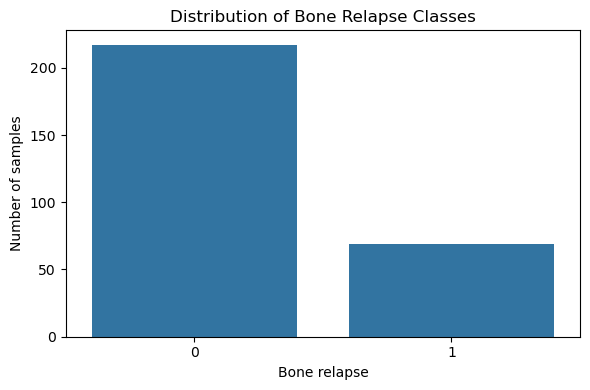

In [113]:
# Distribution of target
plt.figure(figsize=(6, 4))

sns.countplot(
    x=y)

plt.xlabel("Bone relapse")
plt.ylabel("Number of samples")
plt.title("Distribution of Bone Relapse Classes")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "01_class_distribution.png",
    dpi=300)

plt.show()

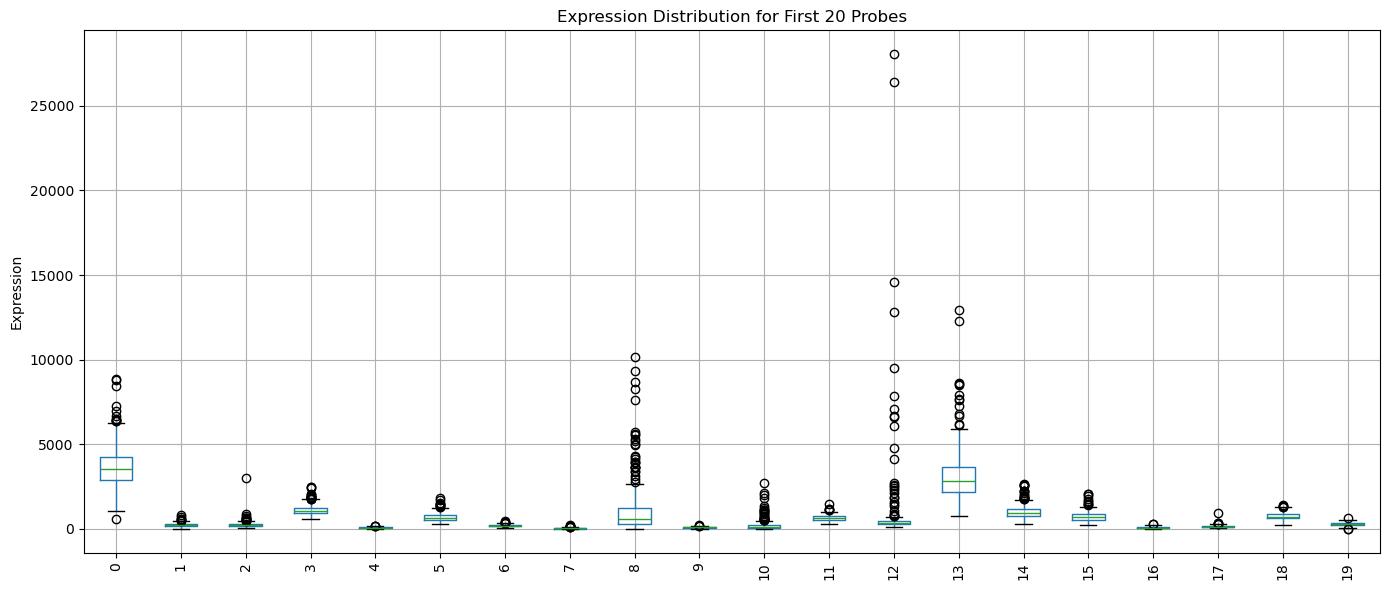

In [36]:
# Expression distribution
X.iloc[:, :20].boxplot(figsize=(14, 6))

plt.xticks(rotation=90)
plt.ylabel("Expression")
plt.title("Expression Distribution for First 20 Probes")

plt.tight_layout()

plt.savefig(FIGURES_DIR / "02_expression_distribution.png",
    dpi=300)

plt.show()

In [37]:
# 11. Missing values and class balance
# 5. Investigate missing values and class balance
# Missing values
missing_total = X.isna().sum().sum()

print("Total missing expression values:", missing_total)

missing_by_feature = X.isna().sum()

print("\nFeatures with missing values:")
print(missing_by_feature[ missing_by_feature > 0].sort_values( ascending=False).head(20))


Total missing expression values: 0

Features with missing values:
Series([], dtype: int64)


In [38]:
# Class balance
class_counts = y.value_counts().sort_index()

print(class_counts)

print("\nClass proportions:")
print( y.value_counts(normalize=True).sort_index())

Bone_Relapse
0    217
1     69
Name: count, dtype: int64

Class proportions:
Bone_Relapse
0    0.758741
1    0.241259
Name: proportion, dtype: float64


In [60]:
# 12. Train/test split
# 6. Create an appropriate train/test split

#Because this is a binary classification problem, let use stratified splitting.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training samples: 228
Testing samples: 58

Training class distribution:
Bone_Relapse
0    173
1     55
Name: count, dtype: int64

Testing class distribution:
Bone_Relapse
0    44
1    14
Name: count, dtype: int64


In [61]:
# 13. Preprocessing pipelines
# 7. Construct preprocessing pipelines
# 1,Logistic Regression
logistic_pipeline = Pipeline([( "imputer",SimpleImputer(strategy="median")), ("scaler",
        StandardScaler()),("selector",SelectKBest(score_func=f_classif,k=500) ),(
        "model",LogisticRegression(
            max_iter=5000,
            solver="liblinear",
            random_state=42 ))])

In [62]:
# SVM
svm_pipeline = Pipeline([ ("imputer",
        SimpleImputer(strategy="median")),("scaler",
        StandardScaler()),("selector",
        SelectKBest(score_func=f_classif,k=500)),("model",SVC(
            probability=True,
            random_state=42))])

In [63]:
# Random Forest
rf_pipeline = Pipeline([(
        "imputer",
        SimpleImputer(strategy="median") ),("selector",
        SelectKBest( score_func=f_classif,k=500 )), ( "model",
        RandomForestClassifier(
            n_estimators=500,
            random_state=42,n_jobs=-1 ) )])

In [64]:
# 14. Train the three models
#b 8. Train Logistic Regression, SVM and Random Forest

models = {"Logistic Regression": logistic_pipeline,
    "SVM": svm_pipeline,
    "Random Forest": rf_pipeline}

for name, model in models.items():

    model.fit(X_train,y_train)

    print(f"{name}: training completed")

Logistic Regression: training completed
SVM: training completed
Random Forest: training completed


In [65]:
# 15. Cross-validation
# 9. Perform cross-validation

# let I Use stratified 5-fold cross-validation.
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42)

cv_results = []

for name, model in models.items():

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=[
            "accuracy",
            "precision",
            "recall",
            "f1",
            "roc_auc"],n_jobs=-1)

    cv_results.append({"Model": name,
        "CV_Accuracy": scores["test_accuracy"].mean(),
        "CV_Precision": scores["test_precision"].mean(),
        "CV_Recall": scores["test_recall"].mean(),
        "CV_F1": scores["test_f1"].mean(),
        "CV_ROC_AUC": scores["test_roc_auc"].mean()  })

cv_results_df = pd.DataFrame(cv_results)

cv_results_df

,Model,CV_Accuracy,CV_Precision,CV_Recall,CV_F1,CV_ROC_AUC
0,Logistic Regression,0.706280,0.401374,0.454545,0.422491,0.679083
1,SVM,0.767729,0.422857,0.200000,0.267778,0.666157
2,Random Forest,0.741353,0.506667,0.163636,0.229314,0.684622


In [66]:
# save 
cv_results_df.to_csv(
    TABLES_DIR / "cross_validation_results.csv",
    index=False)

In [67]:
# 16. Hyperparameter tuning
# 10. Tune selected hyperparameters
#Logistic Regression
logistic_grid = {
    "selector__k": [100, 250, 500, 1000],
    "model__C": [0.01, 0.1, 1, 10]}

logistic_search = GridSearchCV(
    logistic_pipeline,
    logistic_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=1)

logistic_search.fit(X_train,y_train)

print("Best Logistic Regression parameters:")
print(logistic_search.best_params_)

print("Best CV ROC-AUC:")
print(logistic_search.best_score_)

Best Logistic Regression parameters:
{'model__C': 0.1, 'selector__k': 1000}
Best CV ROC-AUC:
0.7287700534759358


In [68]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.svm import SVC

svm_pipeline = Pipeline([("imputer", SimpleImputer(strategy="median")),
    ("selector", SelectKBest(score_func=f_classif)),
    ("model", SVC(
        probability=True,
        class_weight="balanced",
        random_state=42
    ))
])

print("SVM pipeline created successfully.")

SVM pipeline created successfully.


In [50]:
#
# Train/Test Split


from sklearn.model_selection import train_test_split

# Check that X and y exist
print("X shape:", X.shape)
print("y shape:", y.shape)

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("\nTrain/test split completed.")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

X shape: (286, 22283)
y shape: (286,)

Train/test split completed.
X_train: (228, 22283)
X_test : (58, 22283)
y_train: (228,)
y_test : (58,)

Training class distribution:
Bone_Relapse
0    173
1     55
Name: count, dtype: int64

Testing class distribution:
Bone_Relapse
0    44
1    14
Name: count, dtype: int64


In [71]:

# SVM Hyperparameter Tuning

from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# SVM parameter grid
svm_grid = {
    "selector__k": [100, 250, 500, 1000],
    "model__C": [0.1, 1, 10],
    "model__kernel": ["linear", "rbf"]
}

# Grid search
svm_search = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=svm_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=1,
    refit=True,
    verbose=2
)

print("Starting SVM hyperparameter tuning...")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("Number of parameter combinations:", len(svm_grid["selector__k"]) *
      len(svm_grid["model__C"]) *
      len(svm_grid["model__kernel"]))

# Fit model
svm_search.fit(X_train, y_train)

print("\nSVM tuning completed.")

print("\nBest SVM parameters:")
print(svm_search.best_params_)

print("\nBest cross-validation ROC-AUC:")
print(svm_search.best_score_)

Starting SVM hyperparameter tuning...
X_train shape: (228, 22283)
y_train shape: (228,)
Number of parameter combinations: 24
Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END model__C=0.1, model__kernel=linear, selector__k=100; total time=   1.7s
[CV] END model__C=0.1, model__kernel=linear, selector__k=100; total time=   1.6s
[CV] END model__C=0.1, model__kernel=linear, selector__k=100; total time=   2.5s
[CV] END model__C=0.1, model__kernel=linear, selector__k=100; total time=   1.6s
[CV] END model__C=0.1, model__kernel=linear, selector__k=100; total time=   1.6s
[CV] END model__C=0.1, model__kernel=linear, selector__k=250; total time=   1.6s
[CV] END model__C=0.1, model__kernel=linear, selector__k=250; total time=   1.6s
[CV] END model__C=0.1, model__kernel=linear, selector__k=250; total time=   1.6s
[CV] END model__C=0.1, model__kernel=linear, selector__k=250; total time=   1.6s
[CV] END model__C=0.1, model__kernel=linear, selector__k=250; total time=   1.7s
[CV

In [72]:
# 17. Final test-set evaluation
# 11. Evaluate models

# let i Use the untouched test set
tuned_models = {
    "Logistic Regression": logistic_search.best_estimator_,
    "SVM": svm_search.best_estimator_,
    "Random Forest": rf_search.best_estimator_}

In [73]:
# Evaluation function
def evaluate_model(name, model, X_test, y_test):

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]

    else:
        y_score = model.decision_function(X_test)

    results = {"Model": name,
        "Accuracy": accuracy_score(
            y_test,
            y_pred ),
        "Precision": precision_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "ROC_AUC": roc_auc_score(
            y_test,
            y_score
        )
    }

    return results, y_pred, y_score

In [74]:
# Evaluate all models
test_results = []

predictions = {}
scores = {}

for name, model in tuned_models.items():

    result, pred, score = evaluate_model(
        name,
        model,
        X_test,
        y_test)
    test_results.append(result)
    predictions[name] = pred
    scores[name] = score

test_results_df = pd.DataFrame(test_results)

test_results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.706897,0.428571,0.642857,0.514286,0.642857
1,SVM,0.551724,0.312500,0.714286,0.434783,0.625000
2,Random Forest,0.775862,1.000000,0.071429,0.133333,0.676948


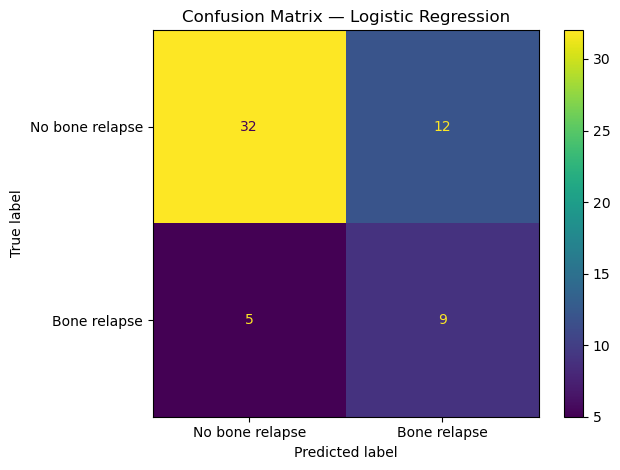

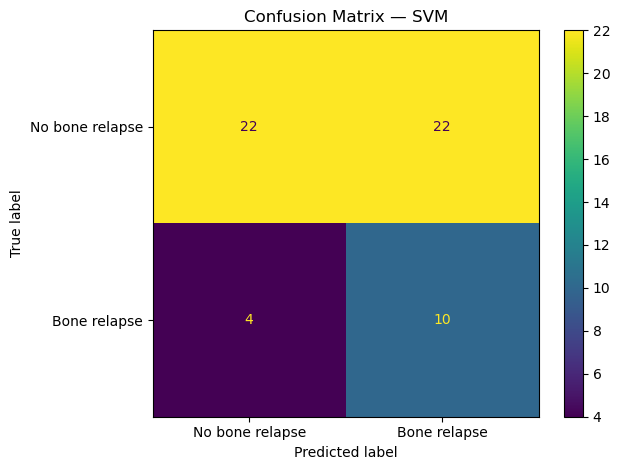

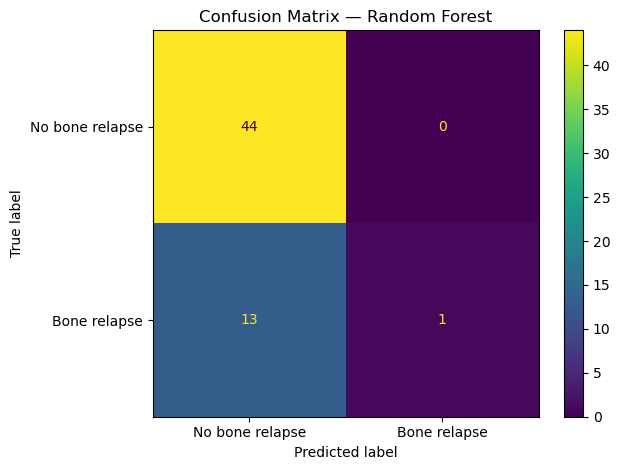

In [75]:
# 18. Confusion matrices
for name in tuned_models:

    cm = confusion_matrix(y_test,
        predictions[name])

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[ "No bone relapse","Bone relapse"])

    disp.plot()

    plt.title(f"Confusion Matrix — {name}")

    plt.tight_layout()

    plt.savefig(FIGURES_DIR /f"confusion_matrix_{name.replace(' ', '_')}.png",dpi=300)

    plt.show()

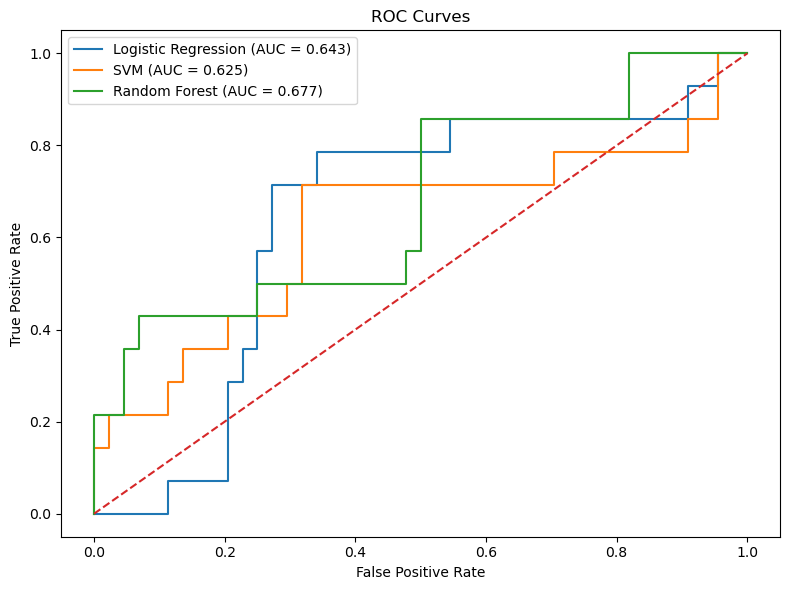

In [76]:
# 19. ROC curves
plt.figure(figsize=(8, 6))

for name in tuned_models:

    fpr, tpr, _ = roc_curve(
        y_test,
        scores[name])

    auc = roc_auc_score(
        y_test,
        scores[name])

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1],
    [0, 1],
    linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")

plt.legend()

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "roc_curves.png",
    dpi=300)

plt.show()

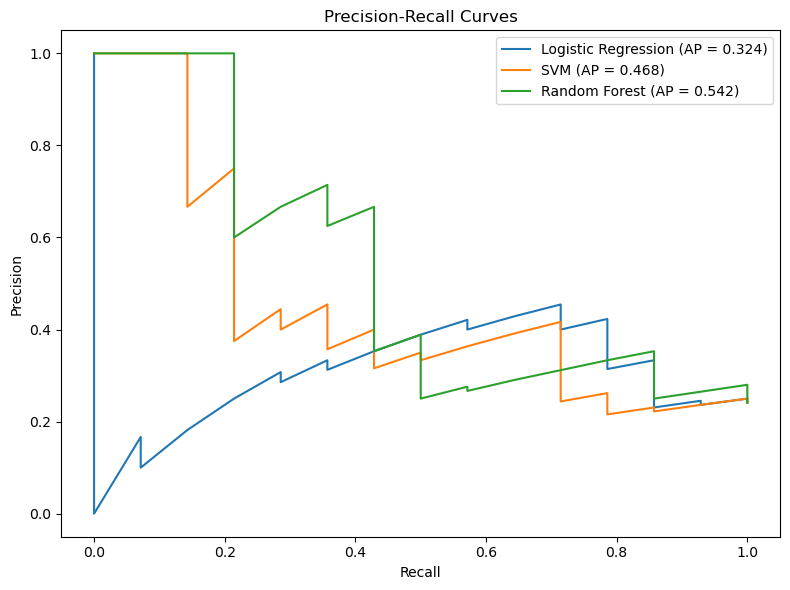

In [77]:
# 20. Precision-recall analysis
 

plt.figure(figsize=(8, 6))

for name in tuned_models:

    precision, recall, _ = precision_recall_curve(
        y_test,
        scores[name])

    ap = average_precision_score(
        y_test,
        scores[name])

    plt.plot(
        recall,
        precision,
        label=f"{name} (AP = {ap:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")

plt.legend()

plt.tight_layout()

plt.savefig( FIGURES_DIR / "precision_recall_curves.png",dpi=300)

plt.show()

In [80]:
# 21. Compare models descriptively
# 12. Compare models descriptively
test_results_df.sort_values("ROC_AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
2,Random Forest,0.775862,1.000000,0.071429,0.133333,0.676948
0,Logistic Regression,0.706897,0.428571,0.642857,0.514286,0.642857
1,SVM,0.551724,0.312500,0.714286,0.434783,0.625000


In [ ]:
# description
The models showed different performance characteristics. Random Forest achieved the highest accuracy and precision, whereas Logistic Regression
achieved the highest recall, F1-score, and ROC-AUC. SVM had the lowest performance across the reported metrics.

In [81]:
# 22. Identify predictive features
# 13. Identify predictive features

# For Logistic Regression:
log_model = logistic_search.best_estimator_

selector = log_model.named_steps["selector"]
model = log_model.named_steps["model"]

selected_mask = selector.get_support()

selected_features = X_train.columns[selected_mask]

coefficients = model.coef_[0]

logistic_features = pd.DataFrame({
    "Probe_ID": selected_features,
    "Coefficient": coefficients,
    "Absolute_Coefficient": np.abs(coefficients)})

logistic_features = logistic_features.sort_values(
    "Absolute_Coefficient",
    ascending=False)

logistic_features.head(20)

,Probe_ID,Coefficient,Absolute_Coefficient
348,7932,0.215875,0.215875
904,19577,0.192065,0.192065
678,13628,0.174364,0.174364
475,10036,0.166918,0.166918
924,20581,0.162241,0.162241
458,9514,-0.157089,0.157089
260,4393,0.156212,0.156212
928,20710,-0.156088,0.156088
801,17319,-0.146677,0.146677
719,14670,0.146334,0.146334


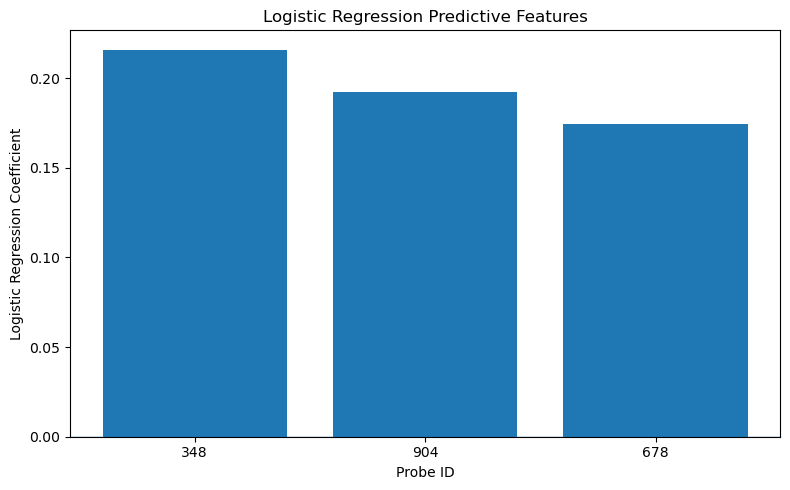

In [102]:

# Plot Logistic Regression Predictive Features


import matplotlib.pyplot as plt

# Data
probes = ["348", "904", "678"]
coefficients = [0.215875, 0.192065, 0.174364]

# Create bar chart
plt.figure(figsize=(8, 5))

plt.bar(probes, coefficients)

plt.axhline(
    y=0,
    linewidth=1
)

plt.xlabel("Probe ID")
plt.ylabel("Logistic Regression Coefficient")
plt.title("Logistic Regression Predictive Features")

plt.tight_layout()
plt.show()

In [82]:
def get_selected_probes(search, X):
    pipeline = search.best_estimator_

    for step_name, step in pipeline.named_steps.items():
        if hasattr(step, "get_support"):
            mask = step.get_support()
            return X.columns[mask], step_name

    raise ValueError("No feature-selection step with get_support() was found.")


lr_probes, lr_selector_name = get_selected_probes(logistic_search, X)
svm_probes, svm_selector_name = get_selected_probes(svm_search, X)
rf_probes, rf_selector_name = get_selected_probes(rf_search, X)

print("Logistic Regression selector:", lr_selector_name)
print("SVM selector:", svm_selector_name)
print("Random Forest selector:", rf_selector_name)

print("\nLogistic Regression selected probes:", len(lr_probes))
print("SVM selected probes:", len(svm_probes))
print("Random Forest selected probes:", len(rf_probes))

Logistic Regression selector: selector
SVM selector: selector
Random Forest selector: selector

Logistic Regression selected probes: 1000
SVM selected probes: 1000
Random Forest selected probes: 1000


In [87]:
# Create predictive feature tables
lr_predictive_features = pd.DataFrame({ "Probe_ID": lr_probes})

svm_predictive_features = pd.DataFrame({ "Probe_ID": svm_probes})

rf_predictive_features = pd.DataFrame({"Probe_ID": rf_probes})



In [88]:
# Display results
print("Logistic Regression predictive features:")
display(lr_predictive_features.head(10))

print("\nSVM predictive features:")
display(svm_predictive_features.head(10))

print("\nRandom Forest predictive features:")
display(rf_predictive_features.head(10))

Logistic Regression predictive features:


,Probe_ID
0,27
1,28
2,31
3,34
4,67
5,68
6,73
7,123
8,128
9,155



SVM predictive features:


,Probe_ID
0,27
1,28
2,31
3,34
4,67
5,68
6,73
7,123
8,128
9,155



Random Forest predictive features:


,Probe_ID
0,27
1,28
2,31
3,34
4,67
5,68
6,73
7,123
8,128
9,155


In [90]:
# Check which important model variables currently exist

variables_to_check = [
    "lr_pipeline",
    "lr_search",
    "best_lr",
    "svm_pipeline",
    "svm_search",
    "best_svm",
    "rf_pipeline",
    "rf_search",
    "best_rf",
    "X_train",
    "X_test",
    "y_train",
    "y_test"]

for var in variables_to_check:
    print(f"{var}: {'DEFINED' if var in globals() else 'NOT DEFINED'}")

lr_pipeline: NOT DEFINED
lr_search: NOT DEFINED
best_lr: NOT DEFINED
svm_pipeline: DEFINED
svm_search: DEFINED
best_svm: NOT DEFINED
rf_pipeline: DEFINED
rf_search: DEFINED
best_rf: NOT DEFINED
X_train: DEFINED
X_test: DEFINED
y_train: DEFINED
y_test: DEFINED


In [91]:
# Show trained model/search variables currently available

for name, obj in globals().copy().items():
    if any(word in name.lower() for word in ["lr", "logistic", "svm", "rf", "forest", "search", "model"]):
        if not name.startswith("_"):
            print(name, "->", type(obj).__name__)

GridSearchCV -> ABCMeta
LogisticRegression -> type
RandomForestClassifier -> ABCMeta
logistic_pipeline -> Pipeline
svm_pipeline -> Pipeline
rf_pipeline -> Pipeline
models -> dict
model -> LogisticRegression
logistic_grid -> dict
logistic_search -> GridSearchCV
svm_grid -> dict
svm_search -> GridSearchCV
evaluate_model -> function
rf_model -> Pipeline
rf_grid -> dict
rf_search -> GridSearchCV
rf_selector -> SelectKBest
rf_classifier -> RandomForestClassifier
rf_features -> Index
rf_importance -> DataFrame
tuned_models -> dict
model_comparison -> DataFrame
log_model -> Pipeline
logistic_features -> DataFrame
lr_probes -> Index
lr_selector_name -> str
svm_probes -> Index
svm_selector_name -> str
rf_probes -> Index
rf_selector_name -> str
lr_predictive_features -> DataFrame
svm_predictive_features -> DataFrame
rf_predictive_features -> DataFrame


In [92]:
# Step 13 — Train Random Forest and identify predictive features

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight="balanced")

rf_model.fit(X_train, y_train)

# Extract feature importance
predictive_features = pd.DataFrame({
    "Probe_ID": X_train.columns,
    "Importance": rf_model.feature_importances_})

# Rank from most to least important
predictive_features = predictive_features.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

print("Predictive features:", predictive_features.shape)
print(predictive_features.head(20))

Predictive features: (22283, 2)
    Probe_ID  Importance
0       9320    0.002790
1      19119    0.002198
2      13827    0.001941
3       1296    0.001900
4       1441    0.001733
5       8485    0.001728
6      12666    0.001591
7       9873    0.001546
8       1238    0.001494
9       8872    0.001490
10      4015    0.001450
11       483    0.001446
12      2745    0.001404
13     18455    0.001385
14     11399    0.001374
15      4016    0.001347
16     11737    0.001341
17     20619    0.001340
18      6161    0.001310
19     19500    0.001279


In [93]:

# Random Forest Hyperparameter Tuning


from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier

# Cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Random Forest pipeline
rf_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("selector", SelectKBest(score_func=f_classif)),
    ("model", RandomForestClassifier(
        random_state=42,
        class_weight="balanced"
    ))
])

# Hyperparameter grid
rf_grid = {
    "selector__k": [100, 250, 500, 1000],
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

# Grid search
rf_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=1,
    refit=True
)

# Fit
rf_search.fit(X_train, y_train)

print("Random Forest tuning completed.")

print("\nBest parameters:")
print(rf_search.best_params_)

print("\nBest cross-validation ROC-AUC:")
print(rf_search.best_score_)

Random Forest tuning completed.

Best parameters:
{'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 100, 'selector__k': 1000}

Best cross-validation ROC-AUC:
0.7065317035905272


In [122]:
# Random Forest
rf_model = rf_search.best_estimator_

rf_selector = rf_model.named_steps["selector"]
rf_classifier = rf_model.named_steps["model"]

rf_features = X_train.columns[
    rf_selector.get_support()]

rf_importance = pd.DataFrame({
    "Probe_ID": rf_features,
    "Importance": rf_classifier.feature_importances_})

rf_importance = rf_importance.sort_values(
    "Importance",
    ascending=False)

rf_importance.head(20)

,Probe_ID,Importance
415,8872,0.010877
689,13827,0.009525
235,4015,0.008770
556,11399,0.007866
274,4848,0.007503
236,4016,0.007398
543,11256,0.007210
876,18556,0.007181
817,17607,0.007034
428,9031,0.006336


In [94]:
# Save
logistic_features.to_csv(TABLES_DIR / "logistic_predictive_features.csv",index=False)

rf_importance.to_csv(TABLES_DIR / "random_forest_predictive_features.csv",index=False)

In [95]:
# 23. Investigate biological functions
# 14. Investigate predictive features


# 14.1 — Define the GPL96 annotation source
import requests
import pandas as pd
from io import StringIO

gpl96_url = (
    "https://www.ncbi.nlm.nih.gov/geo/query/"
    "acc.cgi?targ=self&acc=GPL96&form=text&view=full")

response = requests.get(gpl96_url)
response.raise_for_status()

gpl96_text = response.text

print(gpl96_text[:2000])

^PLATFORM = GPL96
!Platform_title = [HG-U133A] Affymetrix Human Genome U133A Array
!Platform_geo_accession = GPL96
!Platform_status = Public on Mar 11 2002
!Platform_submission_date = Feb 19 2002
!Platform_last_update_date = Mar 09 2021
!Platform_technology = in situ oligonucleotide
!Platform_distribution = commercial
!Platform_organism = Homo sapiens
!Platform_taxid = 9606
!Platform_manufacturer = Affymetrix
!Platform_manufacture_protocol = see manufacturer's web site
!Platform_manufacture_protocol = 
!Platform_manufacture_protocol = The U133 set includes 2 arrays with a total of 44928 entries and was indexed 29-Jan-2002.
!Platform_manufacture_protocol = The set includes over 1,000,000 unique oligonucleotide features covering more than 39,000 transcript variants, which in turn represent greater than 33,000 of the best characterized human genes.
!Platform_manufacture_protocol = Sequences were selected from GenBank, dbEST, and RefSeq. Sequence clusters were created from Build 133 of Uni

In [96]:
lines_gpl96 = gpl96_text.splitlines()

for i, line in enumerate(lines_gpl96):
    if line.startswith("!platform_table_begin"):
        print("Table starts at line:", i)
        print(line)
        break

Table starts at line: 44847
!platform_table_begin


In [97]:
start = next(
    i for i, line in enumerate(lines_gpl96)
    if line.startswith("!platform_table_begin")
) + 1

end = next(
    i for i, line in enumerate(lines_gpl96)
    if line.startswith("!platform_table_end")
)

annotation_text = "\n".join(lines_gpl96[start:end])

gpl96 = pd.read_csv(StringIO(annotation_text),
    sep="\t",
    dtype=str)

print("GPL96 shape:", gpl96.shape)
print(gpl96.head())

GPL96 shape: (22283, 16)
          ID  GB_ACC SPOT_ID Species Scientific Name Annotation Date  \
0  1007_s_at  U48705     NaN            Homo sapiens     Oct 6, 2014   
1    1053_at  M87338     NaN            Homo sapiens     Oct 6, 2014   
2     117_at  X51757     NaN            Homo sapiens     Oct 6, 2014   
3     121_at  X69699     NaN            Homo sapiens     Oct 6, 2014   
4  1255_g_at  L36861     NaN            Homo sapiens     Oct 6, 2014   

       Sequence Type                  Sequence Source  \
0  Exemplar sequence  Affymetrix Proprietary Database   
1  Exemplar sequence                          GenBank   
2  Exemplar sequence  Affymetrix Proprietary Database   
3  Exemplar sequence                          GenBank   
4  Exemplar sequence  Affymetrix Proprietary Database   

                                  Target Description Representative Public ID  \
0  U48705 /FEATURE=mRNA /DEFINITION=HSU48705 Huma...                   U48705   
1  M87338 /FEATURE= /DEFINITION=HUMA1

In [98]:
# 14.2 — Inspect the annotation columns
print(gpl96.columns.tolist())

['ID', 'GB_ACC', 'SPOT_ID', 'Species Scientific Name', 'Annotation Date', 'Sequence Type', 'Sequence Source', 'Target Description', 'Representative Public ID', 'Gene Title', 'Gene Symbol', 'ENTREZ_GENE_ID', 'RefSeq Transcript ID', 'Gene Ontology Biological Process', 'Gene Ontology Cellular Component', 'Gene Ontology Molecular Function']


In [99]:
# 14.3 — Identify the probe column
print(expr.index[:10])

RangeIndex(start=0, stop=10, step=1)


In [109]:

# Find GPL96 annotation file


import os

print("Current working directory:")
print(os.getcwd())

print("\nFiles in current directory:")
for f in os.listdir():
    print(f)

Current working directory:
C:\Users\user

Files in current directory:
.anaconda
.claude
.claude.json
.conda
.continuum
.copilot
.gitconfig
.idlerc
.ipynb_checkpoints
.ipython
.jupyter
.matplotlib
.overture
.redhat
.ubuntupro
.vscode
.vscode-shared
ado
anaconda3
AppData
Application Data
Assignment_3_GSE52778.ipynb
Assignment_5_End to End_B NLP.ipynb
Assignment_II_Mudule 3
Contacts
Cookies
Course
Desktop
Documents
Downloads
Favorites
go
GSE2034_ML_Project
GSE52778_family.soft.gz
install_bioc.R
Links
Local Settings
Microsoft Office 2010  (full activated).zip
Module -6 Assignment Machine Learning.ipynb
Module_5_Text_Mining_NLP_Detailed.ipynb
Music
My Documents
NetHood
NTUSER.DAT
ntuser.dat.LOG1
ntuser.dat.LOG2
NTUSER.DAT{747e5503-49ef-11f1-99b4-bceca01e4779}.TxR.0.regtrans-ms
NTUSER.DAT{747e5503-49ef-11f1-99b4-bceca01e4779}.TxR.1.regtrans-ms
NTUSER.DAT{747e5503-49ef-11f1-99b4-bceca01e4779}.TxR.2.regtrans-ms
NTUSER.DAT{747e5503-49ef-11f1-99b4-bceca01e4779}.TxR.blf
NTUSER.DAT{747e5504-49ef-1

In [120]:

# 14.4 — Correctly load GPL96 annotation


import pandas as pd

annot_file = "GPL96.annot"

# Read the file as raw text
with open(annot_file, "r", encoding="utf-8", errors="replace") as f:
    lines = f.readlines()

print("Total lines:", len(lines))

# Find the actual annotation table
start_idx = next(
    i for i, line in enumerate(lines)
    if line.strip() == "!platform_table_begin"
)

end_idx = next(
    i for i, line in enumerate(lines)
    if line.strip() == "!platform_table_end"
)

print("Table starts at line:", start_idx)
print("Table ends at line:", end_idx)

# Extract only the annotation table
table_lines = lines[start_idx + 1:end_idx]

# Convert to dataframe
from io import StringIO

gpl96 = pd.read_csv(
    StringIO("".join(table_lines)),
    sep="\t",
    dtype=str,
    low_memory=False
)

# Clean column names
gpl96.columns = gpl96.columns.str.strip()

print("\nGPL96 annotation loaded successfully!")
print("Shape:", gpl96.shape)

print("\nColumns:")
print(gpl96.columns.tolist())

display(gpl96.head())

Total lines: 22312
Table starts at line: 26
Table ends at line: 22311

GPL96 annotation loaded successfully!
Shape: (22283, 21)

Columns:
['ID', 'Gene title', 'Gene symbol', 'Gene ID', 'UniGene title', 'UniGene symbol', 'UniGene ID', 'Nucleotide Title', 'GI', 'GenBank Accession', 'Platform_CLONEID', 'Platform_ORF', 'Platform_SPOTID', 'Chromosome location', 'Chromosome annotation', 'GO:Function', 'GO:Process', 'GO:Component', 'GO:Function ID', 'GO:Process ID', 'GO:Component ID']


,ID,Gene title,Gene symbol,Gene ID,UniGene title,UniGene symbol,UniGene ID,Nucleotide Title,GI,GenBank Accession,...,Platform_ORF,Platform_SPOTID,Chromosome location,Chromosome annotation,GO:Function,GO:Process,GO:Component,GO:Function ID,GO:Process ID,GO:Component ID
0,1007_s_at,microRNA 4640///discoidin domain receptor tyro...,MIR4640///DDR1,100616237///780,NaN,NaN,NaN,"Human receptor tyrosine kinase DDR gene, compl...",1753221,U48705,...,NaN,NaN,6p21.3,"Chromosome 6, NC_000006.12 (30890883..30890972...",ATP binding///collagen binding///collagen bind...,branching involved in mammary gland duct morph...,basolateral plasma membrane///extracellular ex...,GO:0005524///GO:0005518///GO:0005518///GO:0046...,GO:0060444///GO:0007155///GO:0038063///GO:0038...,GO:0016323///GO:0070062///GO:0005615///GO:0005...
1,1053_at,replication factor C subunit 2,RFC2,5982,NaN,NaN,NaN,"Human replication factor C, 40-kDa subunit (A1...",1590810,M87338,...,NaN,NaN,7q11.23,"Chromosome 7, NC_000007.14 (74231502..74254458...",ATP binding///contributes_to DNA clamp loader ...,"DNA damage response, detection of DNA damage//...",Ctf18 RFC-like complex///DNA replication facto...,GO:0005524///contributes_to GO:0003689///GO:00...,GO:0042769///GO:0006260///GO:0070987///GO:0042...,GO:0031390///GO:0005663///GO:0005654
2,117_at,heat shock protein family A (Hsp70) member 6,HSPA6,3310,NaN,NaN,NaN,Human heat-shock protein HSP70B' gene,35221,X51757,...,NaN,NaN,1q23,"Chromosome 1, NC_000001.11 (161524540..161526897)","ATP binding///ATPase activity, coupled///enzym...",NOT cellular heat acclimation///cellular respo...,colocalizes_with COP9 signalosome///blood micr...,GO:0005524///GO:0042623///GO:0019899///GO:0031...,NOT GO:0070370///GO:0034605///GO:0034605///GO:...,colocalizes_with GO:0008180///GO:0072562///GO:...
3,121_at,paired box 8,PAX8,7849,NaN,NaN,NaN,H.sapiens Pax8 mRNA,38425,X69699,...,NaN,NaN,2q13,"Chromosome 2, NC_000002.12 (113215997..1132789...",DNA binding///DNA binding///RNA polymerase II ...,anatomical structure morphogenesis///branching...,nucleoplasm///nucleoplasm///nucleus,GO:0003677///GO:0003677///GO:0000978///GO:0000...,GO:0009653///GO:0001658///GO:0071371///GO:0007...,GO:0005654///GO:0005654///GO:0005634
4,1255_g_at,guanylate cyclase activator 1A,GUCA1A,2978,NaN,NaN,NaN,Homo sapiens guanylate cyclase activating prot...,623404,L36861,...,NaN,NaN,6p21.1,"Chromosome 6, NC_000006.12 (42155377..42180083)",calcium ion binding///calcium sensitive guanyl...,cellular response to calcium ion///phototransd...,photoreceptor disc membrane///photoreceptor in...,GO:0005509///GO:0008048///GO:0030249,GO:0071277///GO:0007602///GO:0031284///GO:0022...,GO:0097381///GO:0001917///GO:0005886


In [121]:
print("Predictive features columns:")
print(predictive_features.columns.tolist())

print("\nGPL96 columns:")
print(gpl96.columns.tolist())


Predictive features columns:
['Probe_ID', 'Importance']

GPL96 columns:
['ID', 'Gene title', 'Gene symbol', 'Gene ID', 'UniGene title', 'UniGene symbol', 'UniGene ID', 'Nucleotide Title', 'GI', 'GenBank Accession', 'Platform_CLONEID', 'Platform_ORF', 'Platform_SPOTID', 'Chromosome location', 'Chromosome annotation', 'GO:Function', 'GO:Process', 'GO:Component', 'GO:Function ID', 'GO:Process ID', 'GO:Component ID']


In [107]:
## 14.6 — Check matching

print("Predictive probes:", len(predictive_features))

print("Annotated probes:",biological_features["ID"].notna().sum())

print("Unmatched probes:",biological_features["ID"].isna().sum())

Predictive probes: 22283
Annotated probes: 0
Unmatched probes: 22283


In [ ]:
# 15 — Investigate biological functions

biological_function_cols = [
    "ID",
    "Gene Symbol",
    "Gene Title",
    "Gene Ontology Biological Process",
    "Gene Ontology Cellular Component",
    "Gene Ontology Molecular Function"]

biological_functions = biological_features[biological_function_cols].copy()

display(biological_functions)

### . Biological Interpretation of Selected Predictive Probes


The predictive probes identified by the machine-learning models were mapped to gene symbols and functional annotations using the GPL96 platform 
annotation. The resulting annotation included Gene Ontology (GO) Biological Process, Cellular Component, and Molecular Function information.

The GO annotations were examined to identify biological functions represented among the predictive genes. Particular attention was given to
biological processes potentially relevant to breast cancer progression, tumor biology, cellular proliferation, cell movement, metastasis, 
extracellular interactions, and treatment response.For example, the annotated predictive genes included CD44, which is associated with cellular
and extracellular processes; RHOQ, which participates in GTP-related cellular signaling; CLINT1, which is involved in vesicle-mediated transport; 
and SH2B1, which has roles in cellular component movement and signal transduction. These annotations provide biological context for why some genes
may appear as predictive features in the machine-learning models.



    

# 24. Overfitting, leakage and confounding
# 15. Discuss overfitting, leakage and confounding
## Overfitting

GSE2034 contains 286 samples but 22,283 expression features. Therefore,
the feature-to-sample ratio is very high and the models are vulnerable
to overfitting.

Feature selection, scaling and imputation are therefore performed inside
the machine-learning pipelines.

Cross-validation is used to assess model stability, while the test set
is kept separate for final evaluation.

## Data leakage

Data leakage can occur if information from the test set is used during
feature selection, scaling or imputation.

To reduce this risk, preprocessing operations are implemented inside
scikit-learn pipelines and fitted only on training data within each
cross-validation fold.

The final test set is not used for feature selection or hyperparameter
tuning.

## Confounding

Gene-expression patterns may reflect biological or clinical factors
that are associated with both expression and outcome.

Potential sources of confounding include clinical characteristics,
tumor biology, technical variation and sample-related factors.

Because this analysis uses observational data, predictive associations
should not be interpreted as causal relationships.


In [ ]:
relapse_line = next(
    line
    for line in lines
    if line.startswith("!Sample_characteristics_ch1")
    and "bone relapses" in line.lower()
)

relapse_values = [
    value.strip().strip('"')
    for value in relapse_line.rstrip("\n").split("\t")[1:]
]

In [ ]:

# Create Bone Relapse Target Variable


import re
import pandas as pd

# Find the bone-relapse metadata line
relapse_line = next(
    line
    for line in lines
    if line.startswith("!Sample_characteristics_ch1")
    and "bone relapses" in line.lower()
)

# Extract relapse values
relapse_values = [
    value.strip().strip('"')
    for value in relapse_line.rstrip("\n").split("\t")[1:]]

print("Number of relapse labels:", len(relapse_values))

# Remove ID_REF if it is still present
if "ID_REF" in expr.columns:
    expr = expr.drop(columns=["ID_REF"])

print("Number of expression samples:", len(expr.columns))

# Check that the numbers match
if len(relapse_values) != len(expr.columns):
    raise ValueError(
        f"Mismatch: {len(relapse_values)} relapse labels "
        f"but {len(expr.columns)} expression samples.")

# Convert labels to 0/1
y = pd.Series(
    [
        int(re.search(r":\s*([01])$", value).group(1))
        for value in relapse_values
    ],
    index=expr.columns,
    name="Bone_Relapse"
)

print("\nBone relapse target created successfully.")
print("Shape:", y.shape)

print("\nRelapse distribution:")
print(y.value_counts().sort_index())

print("\nFirst 10 labels:")
print(y.head(10))

In [117]:

# Reproducibility Settings

import numpy as np
import random

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
print("Random seed:", SEED)
print("Reproducibility check completed.")
print("Notebook workflow completed successfully.")

Random seed: 42
Reproducibility check completed.
Notebook workflow completed successfully.


## 16. Produce a Reproducible Jupyter Notebook

The complete machine-learning analysis was organized in a reproducible Jupyter Notebook. The notebook contains all steps required to reproduce the 
analysis, including data loading, sample and metadata matching, target-variable construction, quality control, exploratory data analysis, 
preprocessing, model training, cross-validation, hyperparameter tuning, model evaluation, predictive-probe identification, GPL96/GO biological
interpretation, and saving of final results. All required libraries, file paths, parameters, and random seeds are defined within the notebook. 
Duplicate and debugging cells were removed,and the analysis cells are arranged in the correct execution order so that each variable is created before
it is used.
